In [ ]:
# Public
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Ellipse, Circle
from matplotlib.animation import PillowWriter
import ipywidgets as widgets
from IPython.display import display
from IPython.display import HTML
import os
from pathlib import Path

# Custom
from s01_agents import JointAgent

# Settings
%load_ext autoreload
%autoreload 2

pygame 2.6.1 (SDL 2.28.4, Python 3.11.11)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [ ]:
for i in range(1, 11):  # Adjust range as needed
    save_dir = f"experiments/Independent/SameTargetRewardLargeGrid{i}"
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    save_dir = f"Independent/SameTargetRewardLargeGrid{i}"
    command = f"%run main.py --train --plot --total_ep 1_000_000 --grid_size 11 --epsilon 0.99 --save_dir {save_dir} --target_reward1 20 --target_reward2 20 --together_reward 0 --travel_reward -1"
    print(f"Running: {command}")
    %run main.py --train --total_ep 1_000_000 --grid_size 11 --epsilon 0.99 --save_dir {save_dir} --target_reward1 20 --target_reward2 20 --together_reward 0 --travel_reward -1 --prior_q experiments/priors/OneDiffusion/q_val.pkl 


# %run main.py --train --plot --total_ep 1_000_000 --grid_size 11 --epsilon 0.99 --save_dir Independent/SameTargetRewardLargeGrid --target_reward1 20 --target_reward2 20 --together_reward 0 --travel_reward -1 --prior_q experiments/priors/OneDiffusion/q_val.pkl 

# rewards = pd.read_pickle('experiments/Independent/SameTargetRewardLargeGrid/rewards.pkl')
# reward_data = []
# for series_name in ['rewards_activated', 'rewards_collected', 'cumulative_rewards']:
#     for regime in range(4):
#         for agent in ['a1', 'a2']:
#             s = pd.Series(rewards[series_name][regime][agent], name = f'{series_name}_{agent}_{regime}')
#             reward_data.append(s)
# train_reward_df = pd.DataFrame(reward_data).T

Running: %run main.py --train --plot --total_ep 1_000_000 --grid_size 11 --epsilon 0.99 --save_dir Independent/SameTargetRewardLargeGrid1 --target_reward1 20 --target_reward2 20 --together_reward 0 --travel_reward -1
Frame 10000 completed
Frame 20000 completed
Frame 30000 completed
Frame 40000 completed
Frame 50000 completed
Frame 60000 completed
Frame 70000 completed
Frame 80000 completed
Frame 90000 completed
Frame 100000 completed
Frame 110000 completed
Frame 120000 completed
Frame 130000 completed
Frame 140000 completed
Frame 150000 completed
Frame 160000 completed
Frame 170000 completed
Frame 180000 completed
Frame 190000 completed
Frame 200000 completed
Frame 210000 completed
Frame 220000 completed
Frame 230000 completed
Frame 240000 completed
Frame 250000 completed
Frame 260000 completed
Frame 270000 completed
Frame 280000 completed
Frame 290000 completed
Frame 300000 completed
Frame 310000 completed
Frame 320000 completed
Frame 330000 completed
Frame 340000 completed
Frame 3500

KeyboardInterrupt: 

Running: %run main.py --train --plot --total_ep 1_000_000 --grid_size 11 --epsilon 0.99 --save_dir Independent/SameTargetRewardLargeGrid5 --target_reward1 20 --target_reward2 20 --together_reward 0 --travel_reward -1
Frame 10000 completed
Frame 20000 completed
Frame 30000 completed


In [3]:
rewards = pd.read_pickle('experiments/Independent/SameTargetRewardLargeGrid/rewards.pkl')
reward_data = []
for series_name in ['rewards_activated', 'rewards_collected', 'cumulative_rewards']:
    for regime in range(4):
        for agent in ['a1', 'a2']:
            s = pd.Series(rewards[series_name][regime][agent], name = f'{series_name}_{agent}_{regime}')
            reward_data.append(s)
train_reward_df = pd.DataFrame(reward_data).T

In [ ]:


zone = set()
for tup in [(0, 5), (5, 0), (5, 10), (10, 5)]:
    zone = zone.union(zone_rec(tup, 2))
print(len(zone))

#zone_dist((0, 5), 2)
#zone_rec((0, 5), 2)
#zone_rec((0, 5), 1)


60


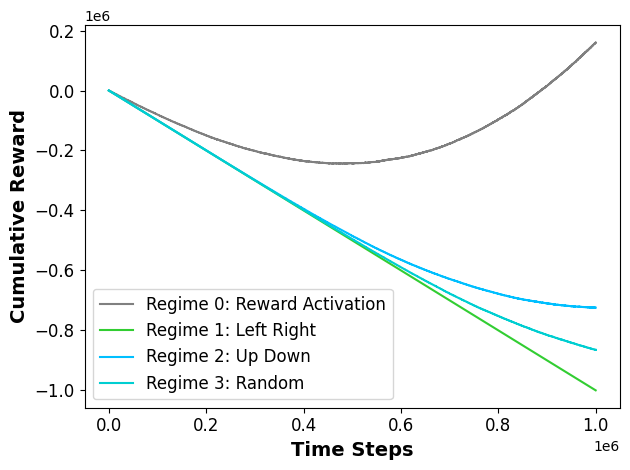

In [4]:
%matplotlib inline
train_reward_df['cumulative_rewards_a1_0'].cumsum().plot(color='grey', label='Regime 0: Reward Activation')
#train_reward_df['cumulative_rewards_a2_0'].cumsum().plot(color='darkred', label='Regime 0')
train_reward_df['cumulative_rewards_a1_1'].cumsum().plot(color='limegreen', label='Regime 1: Left Right')
#train_reward_df['cumulative_rewards_a2_1'].cumsum().plot(color='red', label='Regime 1: Left Right')
train_reward_df['cumulative_rewards_a1_2'].cumsum().plot(color='deepskyblue', label='Regime 2: Up Down')
#train_reward_df['cumulative_rewards_a2_2'].cumsum().plot(color='blue', label='Regime 2: Up Down')
train_reward_df['cumulative_rewards_a1_3'].cumsum().plot(color='darkturquoise', label='Regime 3: Random')
#train_reward_df['cumulative_rewards_a2_3'].cumsum().plot(color='purple', label='Regime 3: Random')
plt.legend(fontsize=12)
plt.ylabel('Cumulative Reward', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('experiments/Independent/SameTargetRewardLargeGrid/cumulative_rewards.png', dpi=600)
plt.show()

In [20]:
%run main.py --eval 10000 --total_ep 50 --grid_size 11 --epsilon_eval 0 --prior_q experiments/Independent/SameTargetRewardLargeGrid3/q_val.pkl --save_dir Independent/SameTargetRewardLargeGrid3/eval

eval_ind = pd.read_pickle('experiments/Independent/SameTargetRewardLargeGrid3/eval/eval.pkl')
eval_ind_flat = [(step[0][0], step[1][0], step[4]) for episode in eval_ind for step in episode][:100]

eval_rewards = pd.read_pickle('experiments/Independent/SameTargetRewardLargeGrid3/eval/rewards_eval.pkl')
reward_data = []
for regime in range(1):
   for series_name in ['success',
                       'rewards_activated',
                       'times_to_activation',
                       'times_to_reward',
                       'deviations_from_reward',
                       'deviations_from_activation',
                       'zones1_counted',
                       'zones2_counted',
                       'zones3_counted',
                       'zones4_counted'
                       ]:
       for agent in ['a1', 'a2']:
           s = pd.Series(rewards[series_name][regime][agent], name = f'{series_name}_{agent}')
           reward_data.append(s)
eval_reward_df = pd.DataFrame(reward_data).T.drop(columns='success_a2').rename(columns={'success_a1': 'success'})

In [21]:
eval_reward_df['rewards_activated_a1'].sum(), eval_reward_df['rewards_activated_a2'].sum()

(np.float64(5007.0), np.float64(4979.0))

In [22]:
print('agent1 time to activation', eval_reward_df
 .query('rewards_activated_a1 == 1.0')
 ['times_to_activation_a1']
 .mean()
 .round(2))

print('agent2 time to activation:', eval_reward_df
 .query('rewards_activated_a2 == 1.0')
 ['times_to_activation_a2']
 .mean()
 .round(2))

agent1 time to activation 3.19
agent2 time to activation: 3.21


In [23]:
print('agent1 percentage in zone1:', eval_reward_df
.query('success == 1.0')
['zones1_counted_a1']
.mean()
.round(3))

print('agent2 percentage in zone1:', eval_reward_df
.query('success == 1.0')
['zones1_counted_a2']
.mean()
.round(3))

print('agent1 percentage in zone1 when 2 is activating:', eval_reward_df
.query('success == 1.0')
.query('rewards_activated_a2 == 1.0')
['zones1_counted_a1']
.mean()
.round(3))

print('agent2 percentage in zone1 when 1 is activating:', eval_reward_df
.query('success == 1.0')
.query('rewards_activated_a1 == 1.0')
['zones1_counted_a2']
.mean()
.round(3))

agent1 percentage in zone1: 0.25
agent2 percentage in zone1: 0.243
agent1 percentage in zone1 when 2 is activating: 0.294
agent2 percentage in zone1 when 1 is activating: 0.28


In [25]:
print('agent1 percentage in zone2:', eval_reward_df
.query('success == 1.0')
['zones2_counted_a1']
.mean()
.round(3))

print('agent2 percentage in zone2:', eval_reward_df
.query('success == 1.0')
['zones2_counted_a2']
.mean()
.round(3))

print('agent1 percentage in zone2 when 2 is activating:', eval_reward_df
.query('success == 1.0')
.query('rewards_activated_a2 == 1.0')
['zones2_counted_a1']
.mean()
.round(3))

print('agent2 percentage in zone2 when 1 is activating:', eval_reward_df
.query('success == 1.0')
.query('rewards_activated_a1 == 1.0')
['zones2_counted_a2']
.mean()
.round(3))

agent1 percentage in zone2: 0.293
agent2 percentage in zone2: 0.283
agent1 percentage in zone2 when 2 is activating: 0.371
agent2 percentage in zone2 when 1 is activating: 0.348


In [26]:
print('agent1 deviation from optimal when activating:', eval_reward_df
.query('rewards_activated_a1 == 1.0')
['deviations_from_activation_a1']
.mean()
.round(3))

print('agent2 deviation from optimal when activating:', eval_reward_df
.query('rewards_activated_a2 == 1.0')
['deviations_from_activation_a2']
.mean()
.round(3))

agent1 deviation from optimal when activating: 4.334
agent2 deviation from optimal when activating: 4.293


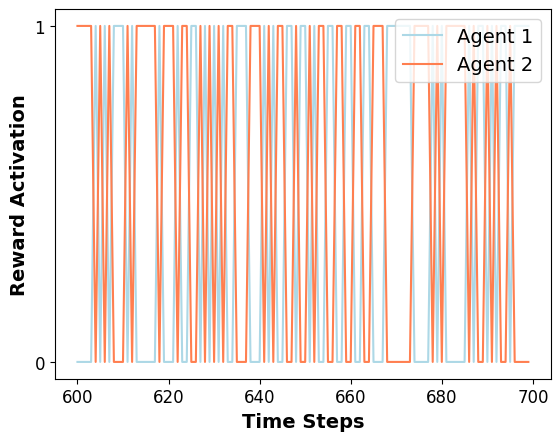

(5008.0, 4980.0, -0.008903160575194812)

In [126]:
%matplotlib inline
plt.plot(eval_reward_df['rewards_activated_a1'][600:700], color='lightblue', label='Agent 1')
plt.plot(eval_reward_df['rewards_activated_a2'][600:700], color='coral', label='Agent 2')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('Time Steps', fontsize=14, fontweight='bold')
plt.ylabel('Reward Activation', fontsize=14, fontweight='bold')
plt.yticks([0, 1], [0, 1], fontsize=12)
plt.xticks(fontsize=12)
plt.savefig('experiments/Independent/SameTargetReward/rewards_activated.png')
plt.show()

eval_reward_df['rewards_activated_a1'].sum(), eval_reward_df['rewards_activated_a2'].sum(), eval_reward_df['rewards_activated_a1'].autocorr(lag=1)

In [25]:
matplotlib.use('Agg')

def rotate_point(x, y, center_x, center_y, angle):
    """Rotate a point (x, y) around a center (center_x, center_y) by a given angle."""
    angle_rad = np.radians(angle)
    x -= center_x
    y -= center_y
    x_new = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_new = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_new + center_x, y_new + center_y

# Grid size
grid_size = 11

# Initialize figure and axis
fig, ax = plt.subplots(figsize=(6,6), dpi=80)
ax.set_xlim(-0.5, grid_size-0.5)
ax.set_ylim(-0.5, grid_size-0.5)
ax.set_xticks(np.arange(-0.5, grid_size, 1))
ax.set_yticks(np.arange(-0.5, grid_size, 1))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True)
ax.legend().remove()

# Create mouse shapes using Ellipse and Circle for both agents
agent1_mouse = Ellipse((0, 0), 0.15, 0.4, angle=45, color='lightblue', alpha=.75, label="Agent 1")
agent1_ear1 = Circle((0.1, 0.1), 0.08, color='lightblue', alpha=.75)
agent1_ear2 = Circle((-0.1, 0.1), 0.08, color='lightblue', alpha=.75)
agent1_tail = Ellipse((0, -.25), 0.03, 0.25, angle=45, color='lightblue', alpha=.75)

agent2_mouse = Ellipse((0, 0), 0.15, 0.4, angle=-45, color='coral', alpha=.75, label="Agent 2")
agent2_ear1 = Circle((0.1, 0.1), 0.08, color='coral', alpha=.75)
agent2_ear2 = Circle((-0.1, 0.1), 0.08, color='coral', alpha=.75)
agent2_tail = Ellipse((0, -.25), 0.03, 0.25, angle=-45, color='coral', alpha=.75)

# Add the shapes to the plot
ax.add_patch(agent1_mouse)
ax.add_patch(agent1_ear1)
ax.add_patch(agent1_ear2)
ax.add_patch(agent1_tail)
ax.add_patch(agent2_mouse)
ax.add_patch(agent2_ear1)
ax.add_patch(agent2_ear2)
ax.add_patch(agent2_tail)

# Other markers
#agent1_marker, = ax.plot([], [], color='blue', marker=(4,2,0), alpha=.8, markersize=12, label="Agent 1", antialiased=False)
#agent2_marker, = ax.plot([], [], color='red', marker=(4,2,45), alpha=.8, markersize=12, label="Agent 2", antialiased=False)
reward_marker, = ax.plot([], [], 'go', alpha=.5, markersize=16, label="Reward", antialiased=False)
center_marker, = ax.plot([], [], 'ys', alpha=.5, markersize=16, label="Center", antialiased=False)



# Function to initialize the plot
def init():
    #agent1_marker.set_data([], [])
    #agent2_marker.set_data([], [])
    agent1_mouse.set_center((0, 0))
    agent1_ear1.set_center((0, 0))
    agent1_ear2.set_center((0, 0))
    agent1_tail.set_center((0, 0))
    
    agent2_mouse.set_center((0, 0))
    agent2_ear1.set_center((0, 0))
    agent2_ear2.set_center((0, 0))
    agent2_tail.set_center((0, 0))
    # reward_marker.set_data([0,grid_size-1], [int(grid_size/2),int(grid_size/2)])
    center_marker.set_data([grid_size//2], [grid_size//2])
    return reward_marker, center_marker, agent1_mouse, agent1_ear1, agent1_ear2, agent1_tail, agent2_mouse, agent2_ear1, agent2_ear2, agent2_tail
# agent1_marker, agent2_marker, 

# Function to update agents' positions

def update(frame):
    step = eval_ind_flat[frame]
    agent1_pos, agent2_pos, reward_pos = step # step[0], step[1], step[2]
    agent1_x, agent1_y = agent1_pos[0], agent1_pos[1]
    agent2_x, agent2_y = agent2_pos[0], agent2_pos[1]
    # agent1_marker.set_data([agent1_x], [agent1_y])
    # agent2_marker.set_data([agent2_x], [agent2_y])
    
    # Rotate Agent 1
    angle1 = 45  # Counter-clockwise rotation
    ear1_x, ear1_y = rotate_point(agent1_x + 0.1, agent1_y + 0.1, agent1_x, agent1_y, angle1)
    ear2_x, ear2_y = rotate_point(agent1_x - 0.1, agent1_y + 0.1, agent1_x, agent1_y, angle1)
    tail_x, tail_y = rotate_point(agent1_x, agent1_y - 0.25, agent1_x, agent1_y, angle1)
    
    agent1_mouse.set_center((agent1_x, agent1_y))
    agent1_ear1.set_center((ear1_x, ear1_y))
    agent1_ear2.set_center((ear2_x, ear2_y))
    agent1_tail.set_center((tail_x, tail_y))
    
    # Rotate Agent 2
    angle2 = -45  # Clockwise rotation
    ear1_x, ear1_y = rotate_point(agent2_x + 0.1, agent2_y + 0.1, agent2_x, agent2_y, angle2)
    ear2_x, ear2_y = rotate_point(agent2_x - 0.1, agent2_y + 0.1, agent2_x, agent2_y, angle2)
    tail_x, tail_y = rotate_point(agent2_x, agent2_y - 0.25, agent2_x, agent2_y, angle2)
    
    agent2_mouse.set_center((agent2_x, agent2_y))
    agent2_ear1.set_center((ear1_x, ear1_y))
    agent2_ear2.set_center((ear2_x, ear2_y))
    agent2_tail.set_center((tail_x, tail_y))    
    reward_marker.set_data([], [])
    if reward_pos:
        reward_x, reward_y = zip(*reward_pos)
        # print(list(reward_x))
        # print(list(reward_y))
        reward_marker.set_data(list(reward_x), list(reward_y))

    return reward_marker, agent1_mouse, agent1_ear1, agent1_ear2, agent1_tail, agent2_mouse, agent2_ear1, agent2_ear2, agent2_tail
# agent1_marker, agent2_marker

ani = animation.FuncAnimation(fig, update, frames=len(eval_ind_flat), init_func=init, blit=True, interval=100)

HTML(ani.to_jshtml())

/tmp/ipykernel_572139/831445265.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


In [127]:
matplotlib.use('Agg')

def rotate_point(x, y, center_x, center_y, angle):
    """Rotate a point (x, y) around a center (center_x, center_y) by a given angle."""
    angle_rad = np.radians(angle)
    x -= center_x
    y -= center_y
    x_new = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_new = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_new + center_x, y_new + center_y

# Grid size
grid_size = 11

# Initialize figure and axis
fig, ax = plt.subplots(figsize=(6,6), dpi=80)
ax.set_xlim(-0.5, grid_size-0.5)
ax.set_ylim(-0.5, grid_size-0.5)
ax.set_xticks(np.arange(-0.5, grid_size, 1))
ax.set_yticks(np.arange(-0.5, grid_size, 1))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True)
ax.legend().remove()

# Create mouse shapes using Ellipse and Circle for both agents
agent1_mouse = Ellipse((0, 0), 0.15, 0.4, angle=45, color='lightblue', alpha=.75, label="Agent 1")
agent1_ear1 = Circle((0.1, 0.1), 0.08, color='lightblue', alpha=.75)
agent1_ear2 = Circle((-0.1, 0.1), 0.08, color='lightblue', alpha=.75)
agent1_tail = Ellipse((0, -.25), 0.03, 0.25, angle=45, color='lightblue', alpha=.75)

agent2_mouse = Ellipse((0, 0), 0.15, 0.4, angle=-45, color='coral', alpha=.75, label="Agent 2")
agent2_ear1 = Circle((0.1, 0.1), 0.08, color='coral', alpha=.75)
agent2_ear2 = Circle((-0.1, 0.1), 0.08, color='coral', alpha=.75)
agent2_tail = Ellipse((0, -.25), 0.03, 0.25, angle=-45, color='coral', alpha=.75)

# Add the shapes to the plot
ax.add_patch(agent1_mouse)
ax.add_patch(agent1_ear1)
ax.add_patch(agent1_ear2)
ax.add_patch(agent1_tail)
ax.add_patch(agent2_mouse)
ax.add_patch(agent2_ear1)
ax.add_patch(agent2_ear2)
ax.add_patch(agent2_tail)

# Other markers
#agent1_marker, = ax.plot([], [], color='blue', marker=(4,2,0), alpha=.8, markersize=12, label="Agent 1", antialiased=False)
#agent2_marker, = ax.plot([], [], color='red', marker=(4,2,45), alpha=.8, markersize=12, label="Agent 2", antialiased=False)
reward_marker, = ax.plot([], [], 'go', alpha=.5, markersize=16, label="Reward", antialiased=False)
center_marker, = ax.plot([], [], 'ys', alpha=.5, markersize=16, label="Center", antialiased=False)



# Function to initialize the plot
def init():
    #agent1_marker.set_data([], [])
    #agent2_marker.set_data([], [])
    agent1_mouse.set_center((0, 0))
    agent1_ear1.set_center((0, 0))
    agent1_ear2.set_center((0, 0))
    agent1_tail.set_center((0, 0))
    
    agent2_mouse.set_center((0, 0))
    agent2_ear1.set_center((0, 0))
    agent2_ear2.set_center((0, 0))
    agent2_tail.set_center((0, 0))
    # reward_marker.set_data([0,grid_size-1], [int(grid_size/2),int(grid_size/2)])
    center_marker.set_data([grid_size//2], [grid_size//2])
    return reward_marker, center_marker, agent1_mouse, agent1_ear1, agent1_ear2, agent1_tail, agent2_mouse, agent2_ear1, agent2_ear2, agent2_tail
# agent1_marker, agent2_marker, 

# Function to update agents' positions

def update(frame):
    step = eval_ind_flat[frame]
    agent1_pos, agent2_pos, reward_pos = step # step[0], step[1], step[2]
    agent1_x, agent1_y = agent1_pos[0], agent1_pos[1]
    agent2_x, agent2_y = agent2_pos[0], agent2_pos[1]
    # agent1_marker.set_data([agent1_x], [agent1_y])
    # agent2_marker.set_data([agent2_x], [agent2_y])
    
    # Rotate Agent 1
    angle1 = 45  # Counter-clockwise rotation
    ear1_x, ear1_y = rotate_point(agent1_x + 0.1, agent1_y + 0.1, agent1_x, agent1_y, angle1)
    ear2_x, ear2_y = rotate_point(agent1_x - 0.1, agent1_y + 0.1, agent1_x, agent1_y, angle1)
    tail_x, tail_y = rotate_point(agent1_x, agent1_y - 0.25, agent1_x, agent1_y, angle1)
    
    agent1_mouse.set_center((agent1_x, agent1_y))
    agent1_ear1.set_center((ear1_x, ear1_y))
    agent1_ear2.set_center((ear2_x, ear2_y))
    agent1_tail.set_center((tail_x, tail_y))
    
    # Rotate Agent 2
    angle2 = -45  # Clockwise rotation
    ear1_x, ear1_y = rotate_point(agent2_x + 0.1, agent2_y + 0.1, agent2_x, agent2_y, angle2)
    ear2_x, ear2_y = rotate_point(agent2_x - 0.1, agent2_y + 0.1, agent2_x, agent2_y, angle2)
    tail_x, tail_y = rotate_point(agent2_x, agent2_y - 0.25, agent2_x, agent2_y, angle2)
    
    agent2_mouse.set_center((agent2_x, agent2_y))
    agent2_ear1.set_center((ear1_x, ear1_y))
    agent2_ear2.set_center((ear2_x, ear2_y))
    agent2_tail.set_center((tail_x, tail_y))    
    reward_marker.set_data([], [])
    if reward_pos:
        reward_x, reward_y = zip(*reward_pos)
        # print(list(reward_x))
        # print(list(reward_y))
        reward_marker.set_data(list(reward_x), list(reward_y))

    return reward_marker, agent1_mouse, agent1_ear1, agent1_ear2, agent1_tail, agent2_mouse, agent2_ear1, agent2_ear2, agent2_tail
# agent1_marker, agent2_marker

ani = animation.FuncAnimation(fig, update, frames=len(eval_ind_flat), init_func=init, blit=True, interval=100)

HTML(ani.to_jshtml())

In [ ]:
# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(eval_ind_flat[:50]), init_func=init, blit=True, interval=100)

# Save as GIF
gif_filename = "animation.gif"
ani.save(gif_filename, writer=PillowWriter(fps=3))

print(f"Animation saved as {gif_filename}")

Animation saved as animation.gif
